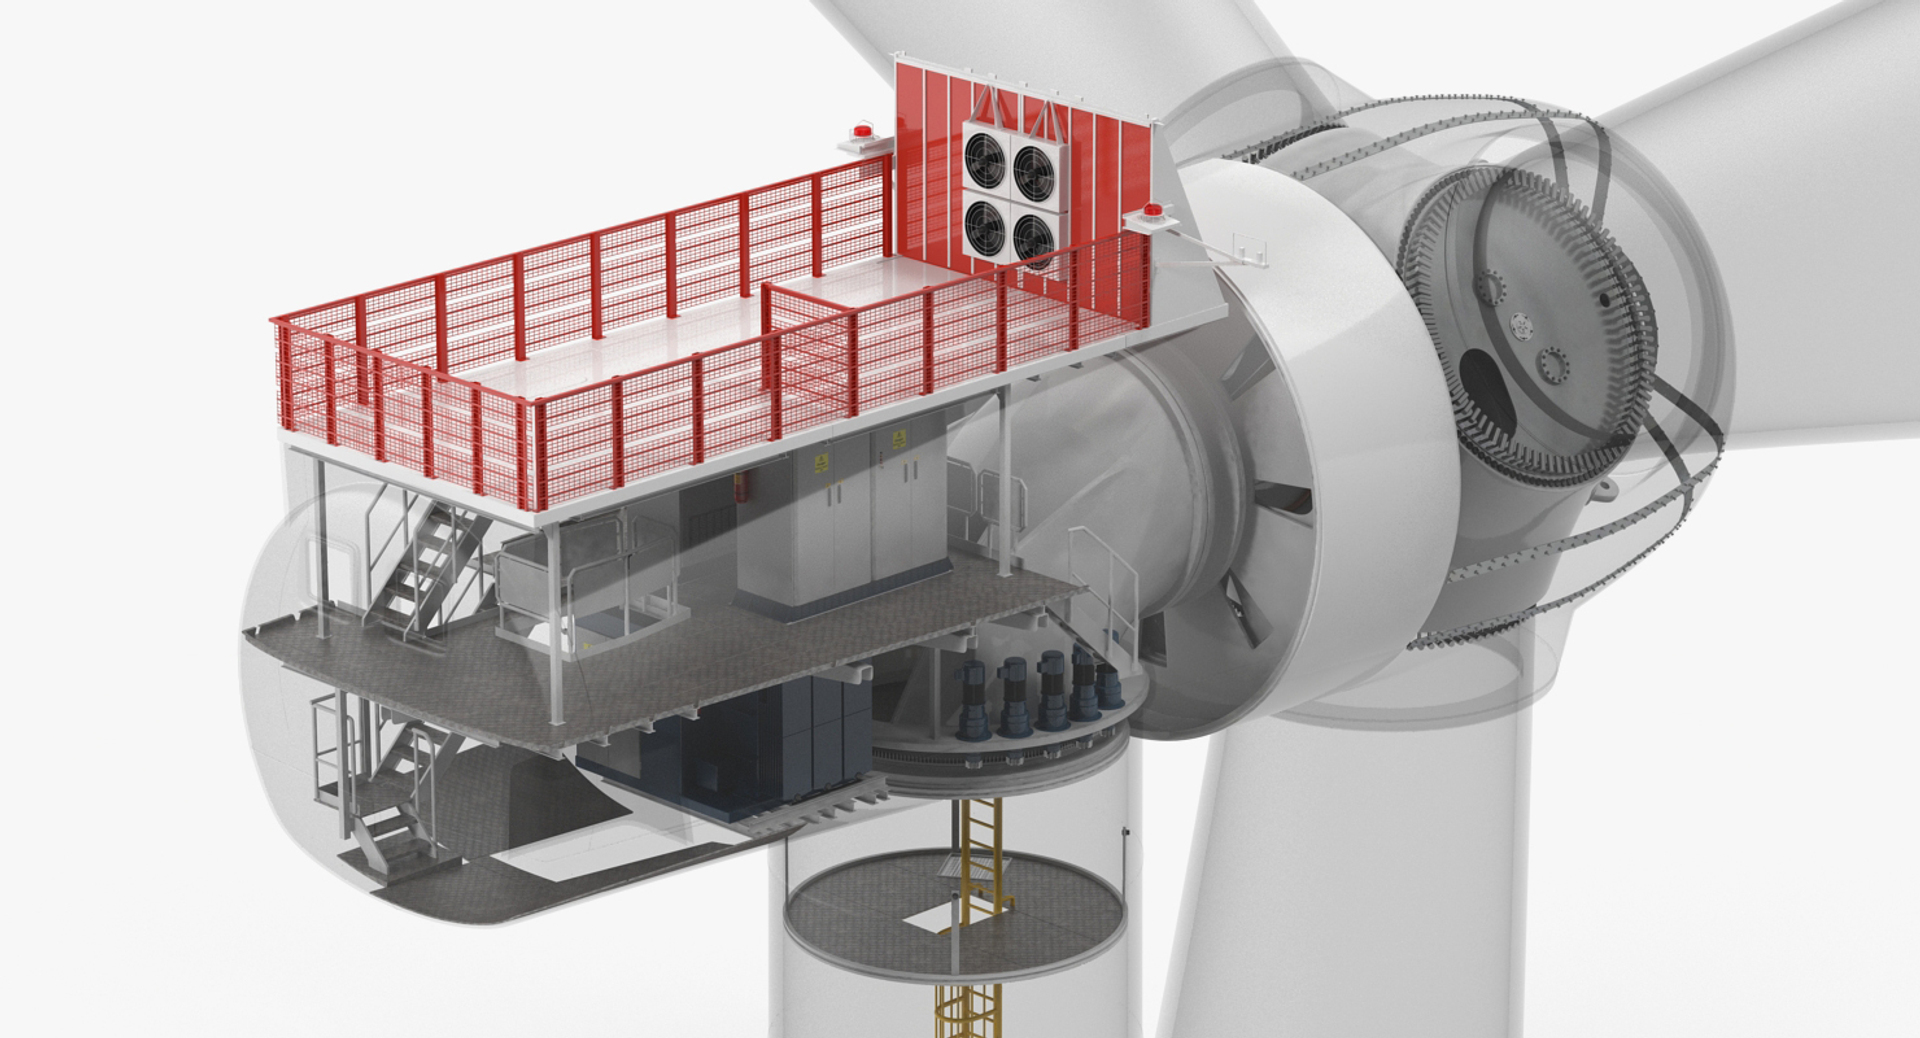

# Разведывательный анализ данных ветрогенератора

**Цель работы.** Провести разведывательный анализ (EDA) набора данных промышленного ветрогенератора с целью изучения структуры данных, выявления закономерностей в режимах работы установки, оценки качества сигналов SCADA и подготовки информационной базы для последующего моделирования (в частности — для задач прогнозирования отказов и режимов простоя).

**Состав исходных данных.** Анализу подлежат три файла:

1. `scada_data.csv` — высокочастотная телеметрия системы SCADA (Supervisory Control and Data Acquisition): скорость ветра, скорость вращения ротора, активная и реактивная мощность, температуры компонентов установки и пр. Регистрация с шагом порядка 10 минут.
2. `status_data.csv` — журнал статусов работы турбины: основной и подчинённый код состояния, текстовая расшифровка, признак сервисного режима и признак аварийного сообщения.
3. `fault_data.csv` — журнал зафиксированных отказов с указанием типа отказа (`GF`, `MF`, `FF`, `AF`, `EF`).

**Структура ноутбука.**

- Раздел 1. Подготовка окружения и загрузка данных.
- Раздел 2. Общий обзор каждой таблицы.
- Раздел 3. Анализ временного покрытия и пропусков.
- Раздел 4. Исследование журнала отказов.
- Раздел 5. Исследование журнала статусов.
- Раздел 6. Анализ телеметрии SCADA: распределения, выбросы, корреляции; сводная таблица признаков по типам отказов.
- Раздел 7. Анализ режимов работы установки по кривой мощности.
- Раздел 8. Сводные выводы и рекомендации к дальнейшему моделированию.

## 1. Подготовка окружения и загрузка данных

В ячейке ниже подключаются библиотеки, задаются параметры отображения и определяется источник данных. Ноутбук рассчитан на запуск в Google Colab: предполагается, что три CSV-файла предварительно загружены в текущий рабочий каталог (через панель *Files* в левой части интерфейса Colab) либо размещены на Google Drive. При необходимости раскомментируйте блок монтирования Drive.

In [1]:
# При работе в Google Colab с файлами на Google Drive раскомментировать:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/wind_turbine_data'

# По умолчанию файлы лежат в текущем рабочем каталоге Colab
DATA_DIR = '.'

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Глобальные настройки отображения
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print('Версии библиотек:')
print(f'  pandas      : {pd.__version__}')
print(f'  numpy       : {np.__version__}')
print(f'  seaborn     : {sns.__version__}')

Версии библиотек:
  pandas      : 2.2.2
  numpy       : 2.0.2
  seaborn     : 0.13.2


In [2]:
# Загрузка всех трёх источников
scada = pd.read_csv(os.path.join(DATA_DIR, 'scada_data.csv'))
status = pd.read_csv(os.path.join(DATA_DIR, 'status_data.csv'))
faults = pd.read_csv(os.path.join(DATA_DIR, 'fault_data.csv'))

# Приведение столбцов времени к единому типу datetime
scada['DateTime'] = pd.to_datetime(scada['DateTime'], errors='coerce')
status['Time'] = pd.to_datetime(status['Time'], dayfirst=True, errors='coerce')
faults['DateTime'] = pd.to_datetime(faults['DateTime'], errors='coerce')

# Сортировка по времени
scada = scada.sort_values('DateTime').reset_index(drop=True)
status = status.sort_values('Time').reset_index(drop=True)
faults = faults.sort_values('DateTime').reset_index(drop=True)

print(f'SCADA  : {scada.shape[0]:>6} строк, {scada.shape[1]:>3} столбцов')
print(f'Status : {status.shape[0]:>6} строк, {status.shape[1]:>3} столбцов')
print(f'Faults : {faults.shape[0]:>6} строк, {faults.shape[1]:>3} столбцов')

SCADA  :  49027 строк,  66 столбцов
Status :   1849 строк,   9 столбцов
Faults :    553 строк,   3 столбцов


## 2. Общий обзор таблиц

Прежде чем переходить к содержательному анализу, фиксируется состав каждой таблицы: типы столбцов, доля пропусков, базовые статистики. Это позволяет на ранних этапах обнаружить очевидные дефекты данных — например, столбцы-константы, ошибки разбора дат или столбцы, ошибочно прочитанные как строковые.

In [3]:
def overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Сводка по таблице: тип, число пропусков, доля пропусков, число уникальных значений."""
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(dropna=True),
    })
    print(f'=== {name} === shape={df.shape}')
    return summary

overview(faults, 'fault_data').head(20)

=== fault_data === shape=(553, 3)


,dtype,n_missing,pct_missing,n_unique
DateTime,datetime64[ns],0,0.000,446
Time,float64,0,0.000,446
Fault,object,0,0.000,5


In [4]:
overview(status, 'status_data').head(20)

=== status_data === shape=(1849, 9)


,dtype,n_missing,pct_missing,n_unique
Time,datetime64[ns],0,0.000,1815
Main Status,int64,0,0.000,29
Sub Status,int64,0,0.000,36
Full Status,object,0,0.000,58
Status Text,object,0,0.000,56
T,int64,0,0.000,4
Service,bool,0,0.000,2
FaultMsg,bool,0,0.000,2
Value0,float64,0,0.000,227


In [5]:
# Для SCADA выводим только первые 25 столбцов, чтобы таблица была обозримой
overview(scada, 'scada_data').head(25)

=== scada_data === shape=(49027, 66)


,dtype,n_missing,pct_missing,n_unique
DateTime,datetime64[ns],0,0.000,49017
Time,int64,0,0.000,49021
Error,int64,0,0.000,12
WEC: ava. windspeed,float64,0,0.000,254
WEC: max. windspeed,float64,0,0.000,360
WEC: min. windspeed,float64,0,0.000,177
WEC: ava. Rotation,float64,0,0.000,1413
WEC: max. Rotation,float64,0,0.000,1548
WEC: min. Rotation,float64,0,0.000,1361
WEC: ava. Power,int64,0,0.000,3067


**Комментарий.** Таблица SCADA содержит порядка 65 числовых каналов. Большинство из них — температуры узлов установки (инверторы, подшипники, статор, ротор, гондола, трансформатор и т.д.). Категориальных признаков в SCADA нет — это благоприятно для построения числовых моделей. В журнале статусов присутствуют как числовые коды (`Main Status`, `Sub Status`), так и логические признаки (`Service`, `FaultMsg`); важно отметить, что эти логические признаки прочитаны как строки и в дальнейшем нуждаются в приведении типов.

In [6]:
# Приведение булевых столбцов журнала статусов
for col in ['Service', 'FaultMsg']:
    status[col] = status[col].map({'TRUE': True, 'FALSE': False, True: True, False: False})

status[['Service', 'FaultMsg']].dtypes

,0
Service,bool
FaultMsg,bool


## 3. Временное покрытие

Прежде чем сводить данные между собой, необходимо убедиться, что временные диапазоны трёх источников действительно пересекаются и что в SCADA нет систематических пропусков (длительных провалов в записи).

In [7]:
def time_range(df, col, name):
    print(f'{name:<8}: с {df[col].min()}  по  {df[col].max()}  '
          f'(длительность: {df[col].max() - df[col].min()})')

time_range(scada,  'DateTime', 'SCADA')
time_range(status, 'Time',     'Status')
time_range(faults, 'DateTime', 'Faults')

SCADA   : с 2014-05-01 00:00:00  по  2015-04-09 00:00:00  (длительность: 343 days 00:00:00)
Status  : с 2014-04-24 12:37:38  по  2015-04-28 22:18:19  (длительность: 369 days 09:40:41)
Faults  : с 2014-05-14 14:39:44  по  2015-01-15 23:09:20  (длительность: 246 days 08:29:36)


Уже на этапе вывода диапазонов видно ключевое наблюдение: **три источника покрывают разные временные интервалы**. Это нужно подчеркнуть отдельно и наглядно, поскольку именно длительность пересечения определяет, какая часть SCADA-данных в принципе может быть размечена событиями из журналов отказов и статусов. График ниже отображает каждый источник как горизонтальную полосу, где каждая точка соответствует одной записи.

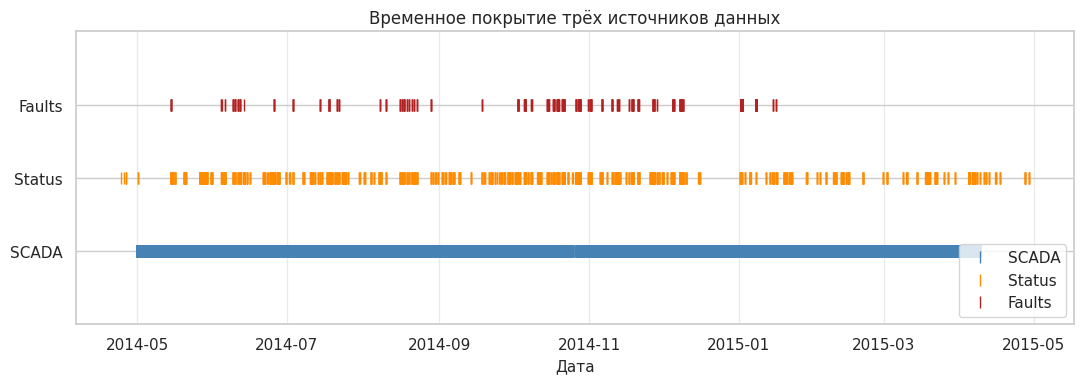

In [8]:
# Визуализация временного покрытия трёх источников в виде горизонтальных полос
t_scada  = scada['DateTime']
t_status = status['Time']
t_fault  = faults['DateTime']

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_scada,  np.full(len(t_scada),  1), '|', markersize=8, color='steelblue', label='SCADA')
ax.plot(t_status, np.full(len(t_status), 2), '|', markersize=8, color='darkorange', label='Status')
ax.plot(t_fault,  np.full(len(t_fault),  3), '|', markersize=8, color='firebrick', label='Faults')

ax.set_ylim(0, 4)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['SCADA', 'Status', 'Faults'])
ax.set_xlabel('Дата')
ax.set_title('Временное покрытие трёх источников данных')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.4, axis='x')
plt.tight_layout()
plt.show()

In [9]:
# Точная количественная оценка пересечения временных периодов
common_start = max(t_scada.min(), t_status.min(), t_fault.min())
common_end   = min(t_scada.max(), t_status.max(), t_fault.max())

in_common = (scada['DateTime'] >= common_start) & (scada['DateTime'] <= common_end)
share_in  = in_common.mean() * 100
share_out = (1 - in_common.mean()) * 100

print(f'Общий период пересечения: с {common_start}  по  {common_end}')
print(f'Длительность пересечения: {common_end - common_start}')
print()
print(f'SCADA-записей внутри пересечения: {in_common.sum():>6} ({share_in:.1f} %)')
print(f'SCADA-записей вне  пересечения:   {(~in_common).sum():>6} ({share_out:.1f} %)')

Общий период пересечения: с 2014-05-14 14:39:44  по  2015-01-15 23:09:20
Длительность пересечения: 246 days 08:29:36

SCADA-записей внутри пересечения:  35168 (71.7 %)
SCADA-записей вне  пересечения:    13859 (28.3 %)


**Комментарий.** Журнал отказов охватывает только часть периода SCADA — примерно с середины мая 2014 года по середину января 2015 года, тогда как SCADA-телеметрия записывалась с 1 мая 2014 года по начало апреля 2015 года, а журнал статусов — ещё шире. Это означает, что почти треть SCADA-записей лежит вне периода, охваченного журналом отказов: для этих интервалов **отсутствие записи об отказе нельзя интерпретировать как «отказ не произошёл»** — соответствующая часть данных просто не размечена. При формировании обучающей выборки для задач классификации это разграничение критично: SCADA-наблюдения за пределами общего периода либо исключаются, либо помечаются как немаркированные.

In [10]:
# Анализ шага дискретизации SCADA
scada_dt = scada['DateTime'].diff().dropna()
print('Распределение интервалов между соседними записями SCADA:')
print(scada_dt.describe())

# Доля интервалов, существенно превышающих типовой шаг 10 минут
long_gaps = scada_dt[scada_dt > pd.Timedelta(minutes=15)]
print(f'\nЧисло разрывов длительностью более 15 минут: {len(long_gaps)}')
print(f'Суммарная длительность таких разрывов: {long_gaps.sum()}')

Распределение интервалов между соседними записями SCADA:
count                        49026
mean     0 days 00:10:04.479255905
std      0 days 00:09:53.534904554
min                0 days 00:00:00
25%                0 days 00:09:00
50%                0 days 00:10:00
75%                0 days 00:11:00
max                1 days 10:31:00
Name: DateTime, dtype: object

Число разрывов длительностью более 15 минут: 13
Суммарная длительность таких разрывов: 2 days 17:38:00


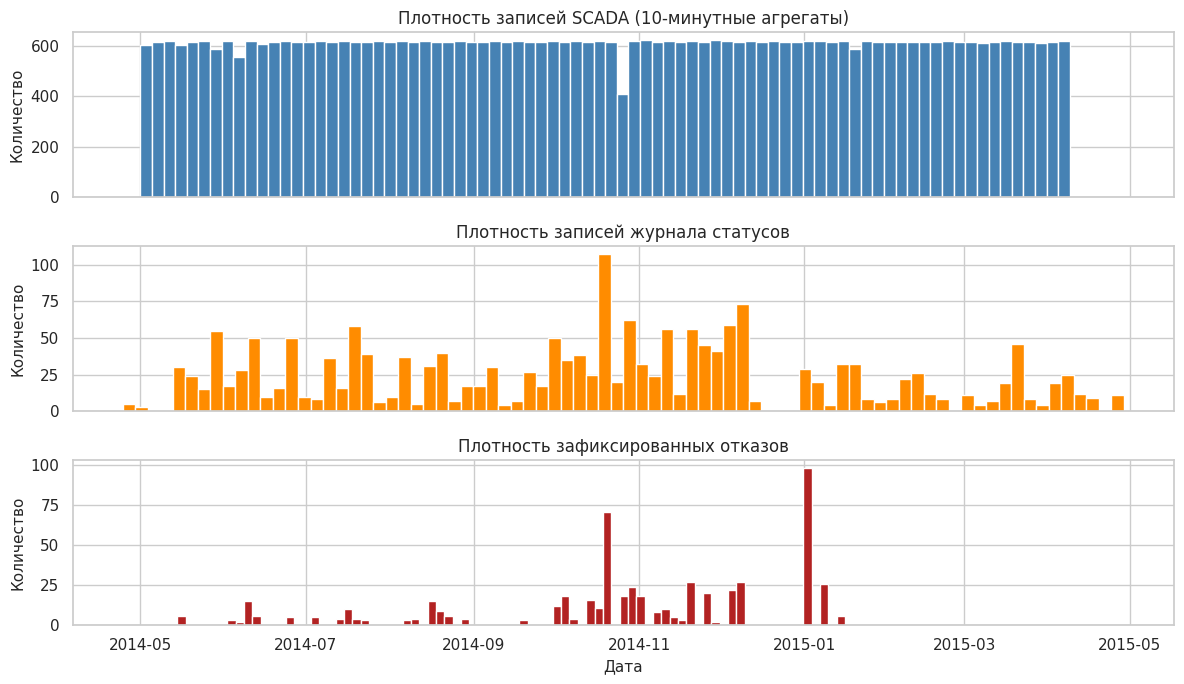

In [11]:
# Визуализация плотности записей по времени для всех трёх источников
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)

axes[0].hist(scada['DateTime'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Плотность записей SCADA (10-минутные агрегаты)')
axes[0].set_ylabel('Количество')

axes[1].hist(status['Time'], bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Плотность записей журнала статусов')
axes[1].set_ylabel('Количество')

axes[2].hist(faults['DateTime'], bins=80, color='firebrick', edgecolor='white')
axes[2].set_title('Плотность зафиксированных отказов')
axes[2].set_ylabel('Количество')
axes[2].set_xlabel('Дата')

plt.tight_layout()
plt.show()

**Комментарий.** SCADA-телеметрия и журналы статусов имеют существенно различную природу: первая регистрируется через равные интервалы (как правило, 10 минут), второй — событийный, записи возникают только в моменты смены состояния. Это нужно учитывать при объединении: события из `status_data` и `fault_data` должны быть привязаны к ближайшему окну SCADA, а не наоборот.

## 4. Журнал отказов

Файл `fault_data.csv` содержит зафиксированные отказы установки, классифицированные по типу. В исходных данных используются короткие коды; ниже приведена их расшифровка для рассматриваемого набора данных:

- **GF** (Generator Heating Fault) — отказ, связанный с перегревом генератора;
- **MF** (Mains Failure Fault) — отказ электросети (сбой во внешнем питании / сетевом подключении);
- **FF** (Feeding Fault) — отказ в системе подачи / преобразования энергии;
- **AF** (Air Cooling Fault) — отказ системы воздушного охлаждения;
- **EF** (Excitation Fault) — отказ системы возбуждения.

С точки зрения физического смысла эти отказы относятся к разным подсистемам установки: генератор и его охлаждение (`GF`, `AF`), электрическая часть (`MF`, `FF`, `EF`). Это разграничение полезно учитывать при последующем анализе совместно с температурными каналами SCADA.

In [12]:
fault_counts = faults['Fault'].value_counts()
fault_share = (fault_counts / fault_counts.sum() * 100).round(1)

fault_table = pd.DataFrame({'count': fault_counts, 'share_%': fault_share})
print('Распределение отказов по типам (только записи журнала отказов):')
print(fault_table)

Распределение отказов по типам (только записи журнала отказов):
       count  share_%
Fault                
FF       254   45.900
EF       174   31.500
AF        62   11.200
GF        43    7.800
MF        20    3.600


Само по себе распределение по типам отказов уже неравномерное (`FF` и `EF` доминируют над `MF`, `GF`, `AF`). Однако ключевой дисбаланс возникает не между типами отказов, а между **состоянием отказа в целом и нормальной работой**. Журнал `fault_data` содержит только моменты отказов; чтобы корректно показать перекос, необходимо построить распределение в контексте всех 10-минутных окон SCADA — где подавляющее большинство соответствует штатной работе. Введём метку `NF` (No Fault) для интервалов SCADA без зафиксированного отказа в пределах окна ±10 минут от записи журнала отказов.

Этот срез строится в пределах общего периода пересечения трёх источников, чтобы не приписывать состояние `NF` интервалам, где журнал отказов отсутствует.

Распределение режимов работы (с учётом нормального режима NF):
       count  share_%
Fault                
NF     34610   98.410
FF       210    0.600
EF       210    0.600
AF        79    0.220
GF        46    0.130
MF        13    0.040


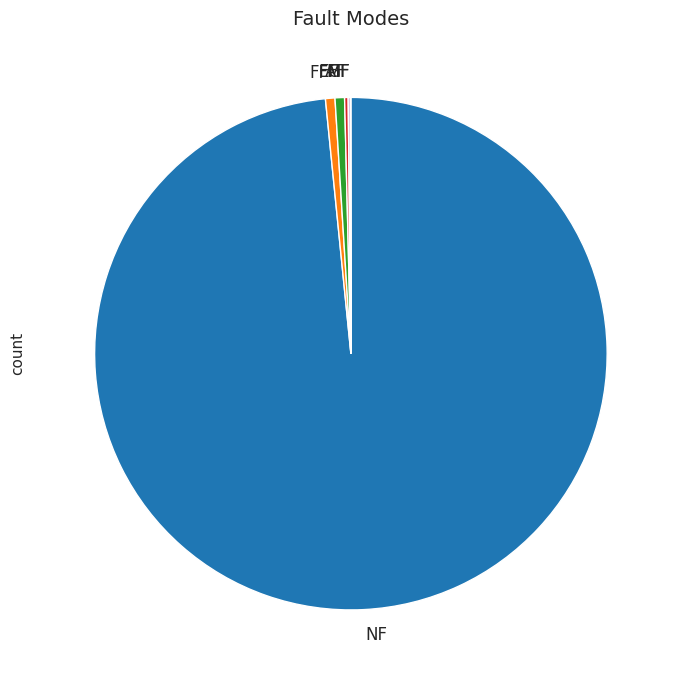

In [13]:
# Размечаем каждое 10-минутное окно SCADA внутри общего периода либо типом отказа,
# либо меткой 'NF' (нормальная работа без зафиксированного отказа).
scada_common = scada.loc[in_common, ['DateTime']].copy()
scada_common = scada_common.sort_values('DateTime').reset_index(drop=True)

faults_sorted = faults.sort_values('DateTime').reset_index(drop=True)

# Сопоставление каждого окна SCADA ближайшей записи отказа (в пределах ±10 минут)
merged = pd.merge_asof(
    scada_common,
    faults_sorted[['DateTime', 'Fault']],
    on='DateTime',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=10),
)
merged['Fault'] = merged['Fault'].fillna('NF')

modes_counts = merged['Fault'].value_counts()
modes_share = (modes_counts / modes_counts.sum() * 100).round(2)
modes_table = pd.DataFrame({'count': modes_counts, 'share_%': modes_share})
print('Распределение режимов работы (с учётом нормального режима NF):')
print(modes_table)

# Упорядочиваем категории по убыванию частоты, NF — первой
ordered = ['NF'] + [c for c in ['FF', 'EF', 'AF', 'GF', 'MF'] if c in modes_counts.index]
modes_counts = modes_counts.reindex(ordered)

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
ax.pie(modes_counts, labels=modes_counts.index, colors=colors,
       startangle=90, counterclock=False,
       textprops={'fontsize': 12})
ax.set_title('Fault Modes', fontsize=14)
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

**Комментарий о перекосе данных.** Круговая диаграмма наглядно демонстрирует, что задача является **сильно несбалансированной**: класс `NF` (нормальная работа) доминирует и составляет существенно большую часть наблюдений, тогда как все типы отказов суммарно занимают меньшую долю. Внутри отказов также присутствует вторичный дисбаланс — преобладают `FF` и `EF`, а `AF`, `GF`, `MF` представлены лишь несколькими процентами каждый.

Практические следствия для моделирования:

1. Простая метрика accuracy здесь непригодна — модель, предсказывающая «всегда NF», получит высокую долю правильных ответов, не имея практической ценности. Следует ориентироваться на recall по классам отказов, F1, PR-AUC.
2. На этапе обучения требуется либо балансировка (under-/over-sampling, class weights), либо переход к задаче one-class / novelty detection с обучением только на нормальном режиме.
3. Малые классы (`MF`, `GF`, `AF`) могут не иметь достаточного числа примеров для построения отдельной модели; их разумно объединять либо рассматривать как обнаружение аномалий.

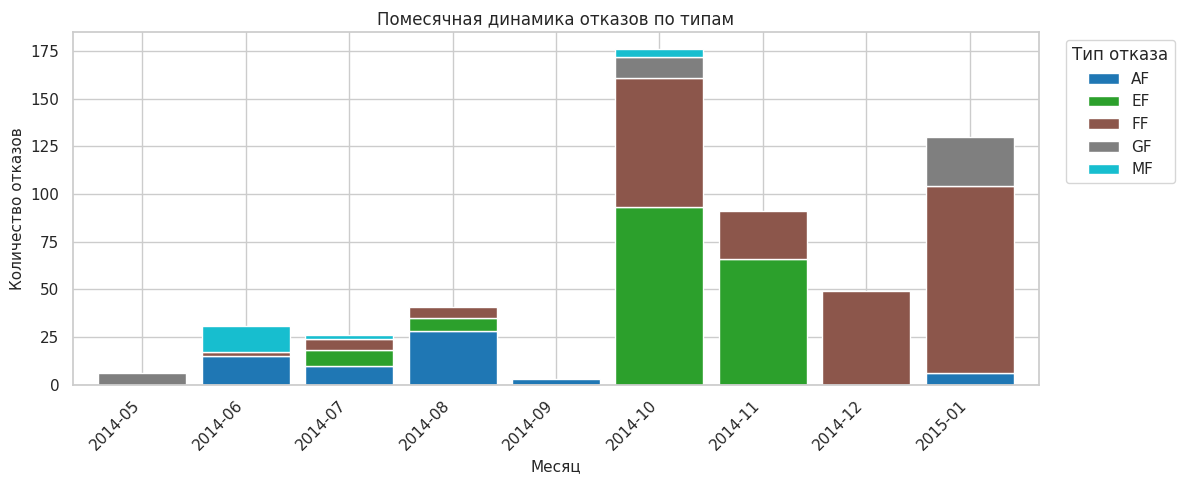

In [14]:
# Помесячная динамика отказов
faults['year_month'] = faults['DateTime'].dt.to_period('M')
monthly = (faults.groupby(['year_month', 'Fault']).size()
                 .unstack(fill_value=0))
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(kind='bar', stacked=True, ax=ax,
             colormap='tab10', edgecolor='white', width=0.85)
ax.set_title('Помесячная динамика отказов по типам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество отказов')
ax.set_xticklabels([d.strftime('%Y-%m') for d in monthly.index], rotation=45, ha='right')
ax.legend(title='Тип отказа', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

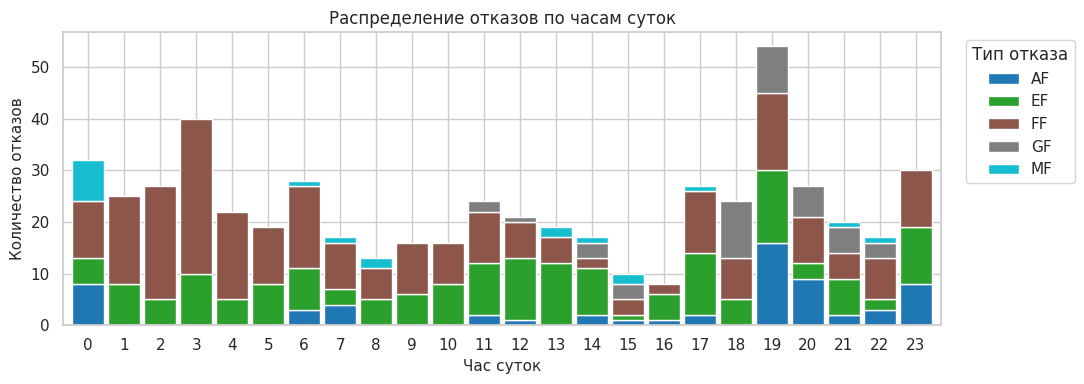

In [15]:
# Распределение отказов по времени суток
faults['hour'] = faults['DateTime'].dt.hour
hourly = faults.groupby(['hour', 'Fault']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 4))
hourly.plot(kind='bar', stacked=True, ax=ax,
            colormap='tab10', edgecolor='white', width=0.9)
ax.set_title('Распределение отказов по часам суток')
ax.set_xlabel('Час суток')
ax.set_ylabel('Количество отказов')
ax.legend(title='Тип отказа', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Комментарий.** Доминирующими типами в выборке являются `FF` и `EF` — отказы системы подачи и системы возбуждения; их совокупная доля превышает 75 %. С учётом физической природы это согласуется с типичной картиной эксплуатации: электрические подсистемы (преобразование энергии и возбуждение генератора) являются наиболее нагруженными узлами и регистрируют большее число событий. Перегрев генератора (`GF`) и отказы системы воздушного охлаждения (`AF`) встречаются заметно реже, но представляют особый интерес: эти классы тесно связаны с температурными каналами SCADA и потенциально допускают раннее обнаружение по тренду температур. Отказы электросети (`MF`) — самый редкий класс — носят внешний характер по отношению к установке.

## 5. Журнал статусов

Журнал статусов фиксирует все смены режимов работы турбины. Один и тот же физический процесс может многократно повторяться в журнале — например, многократные старты в условиях слабого ветра. Анализ выполняется по нескольким срезам: топовые статусы по частоте, доля сервисных и аварийных событий, длительности нахождения в каждом статусе.

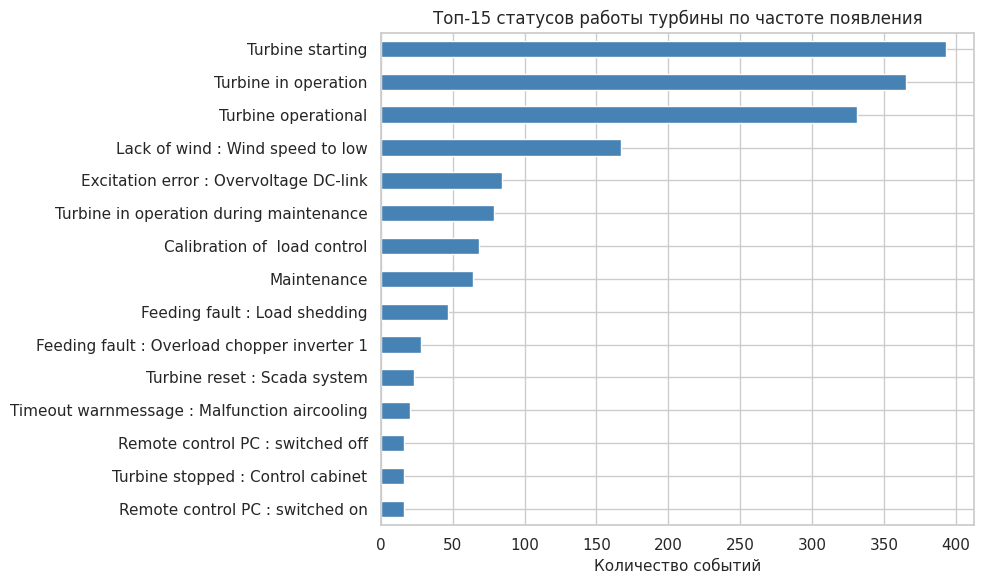

In [16]:
# Топ-15 текстовых статусов по частоте появления
top_statuses = status['Status Text'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_statuses[::-1].plot(kind='barh', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Топ-15 статусов работы турбины по частоте появления')
ax.set_xlabel('Количество событий')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [17]:
# Доли сервисных событий и аварийных сообщений
shares = pd.DataFrame({
    'Service (плановое обслуживание)': status['Service'].mean(),
    'FaultMsg (сообщение об отказе)': status['FaultMsg'].mean(),
}, index=['доля от всех записей']).T * 100

shares.columns = ['доля, %']
print(shares.round(2))

# Совместное распределение Service x FaultMsg
ct = pd.crosstab(status['Service'], status['FaultMsg'],
                 rownames=['Service'], colnames=['FaultMsg'])
print('\nСовместное распределение признаков:')
print(ct)

                                 доля, %
Service (плановое обслуживание)    3.460
FaultMsg (сообщение об отказе)     1.510

Совместное распределение признаков:
FaultMsg  False  True 
Service               
False      1758     27
True         63      1


In [18]:
# Оценка длительности нахождения в каждом статусе.
# Длительность статуса = разница между его началом и началом следующего события.
status_sorted = status.sort_values('Time').copy()
status_sorted['next_time'] = status_sorted['Time'].shift(-1)
status_sorted['duration_min'] = (
    (status_sorted['next_time'] - status_sorted['Time']).dt.total_seconds() / 60
)

duration_by_status = (status_sorted.groupby('Status Text')['duration_min']
                      .agg(['count', 'sum', 'median'])
                      .sort_values('sum', ascending=False)
                      .head(15))
duration_by_status.columns = ['число эпизодов', 'суммарно, мин', 'медиана, мин']
print('Топ-15 статусов по суммарной длительности:')
duration_by_status.round(1)

Топ-15 статусов по суммарной длительности:


,число эпизодов,"суммарно, мин","медиана, мин"
Status Text,,,
Turbine in operation,364,"466,627.700",400.400
Maintenance,64,"40,925.800",122.700
Lack of wind : Wind speed to low,167,"12,793.500",53.400
Remote control PC : switched off,16,"3,683.000",70.400
Remote control PC : Timeout receivebuffer,1,"2,579.500","2,579.500"
Turbine in operation during maintenance,79,955.000,2.200
Feeding fault : No zero crossing several inv.,8,951.200,57.000
Insulation monitoring : Insulation fault Phase U2,1,842.800,842.800
Turbine starting,393,705.800,1.100


**Комментарий.** Полезно отличать частоту от суммарной длительности. Статус с самым большим числом эпизодов (например, многократные запуски) не обязательно занимает много времени в календаре, тогда как редкие, но длительные простои могут сильно влиять на доступность установки. Эта таблица показывает «где турбина действительно проводит время».

## 6. Телеметрия SCADA

Этот раздел посвящён основной части набора данных — числовым каналам SCADA. Анализ строится в три этапа: (а) распределения ключевых физических переменных, (б) детекция аномальных значений, (в) корреляционная структура каналов и группировка по физическому смыслу.

In [19]:
# Базовые физические каналы установки
key_channels = [
    'WEC: ava. windspeed',
    'WEC: ava. Rotation',
    'WEC: ava. Power',
    'WEC: ava. reactive Power',
    'WEC: ava. blade angle A',
    'Nacelle ambient temp. 1',
    'Ambient temp.',
    'Front bearing temp.',
    'Rear bearing temp.',
    'Stator temp. 1',
    'Rotor temp. 1',
    'Transformer temp.',
]
scada[key_channels].describe().T

,count,mean,std,min,25%,50%,75%,max
WEC: ava. windspeed,"49,027.000",6.875,3.695,0.000,4.200,6.500,8.900,32.100
WEC: ava. Rotation,"49,027.000",8.679,4.143,0.000,6.330,8.970,11.920,14.730
WEC: ava. Power,"49,027.000",942.261,"1,008.930",0.000,87.000,536.000,"1,551.000","3,071.000"
WEC: ava. reactive Power,"49,027.000",81.691,84.216,-8.000,29.000,48.000,107.000,425.000
WEC: ava. blade angle A,"49,027.000",10.262,25.015,0.000,1.000,1.000,1.040,327.670
Nacelle ambient temp. 1,"49,027.000",12.512,4.749,0.000,9.000,13.000,16.000,28.000
Ambient temp.,"49,027.000",13.380,5.246,0.000,9.000,13.000,17.000,35.000
Front bearing temp.,"49,027.000",22.062,4.964,0.000,19.000,23.000,26.000,35.000
Rear bearing temp.,"49,027.000",27.290,5.321,0.000,25.000,28.000,31.000,43.000
Stator temp. 1,"49,027.000",60.808,23.755,0.000,45.000,62.000,74.000,119.000


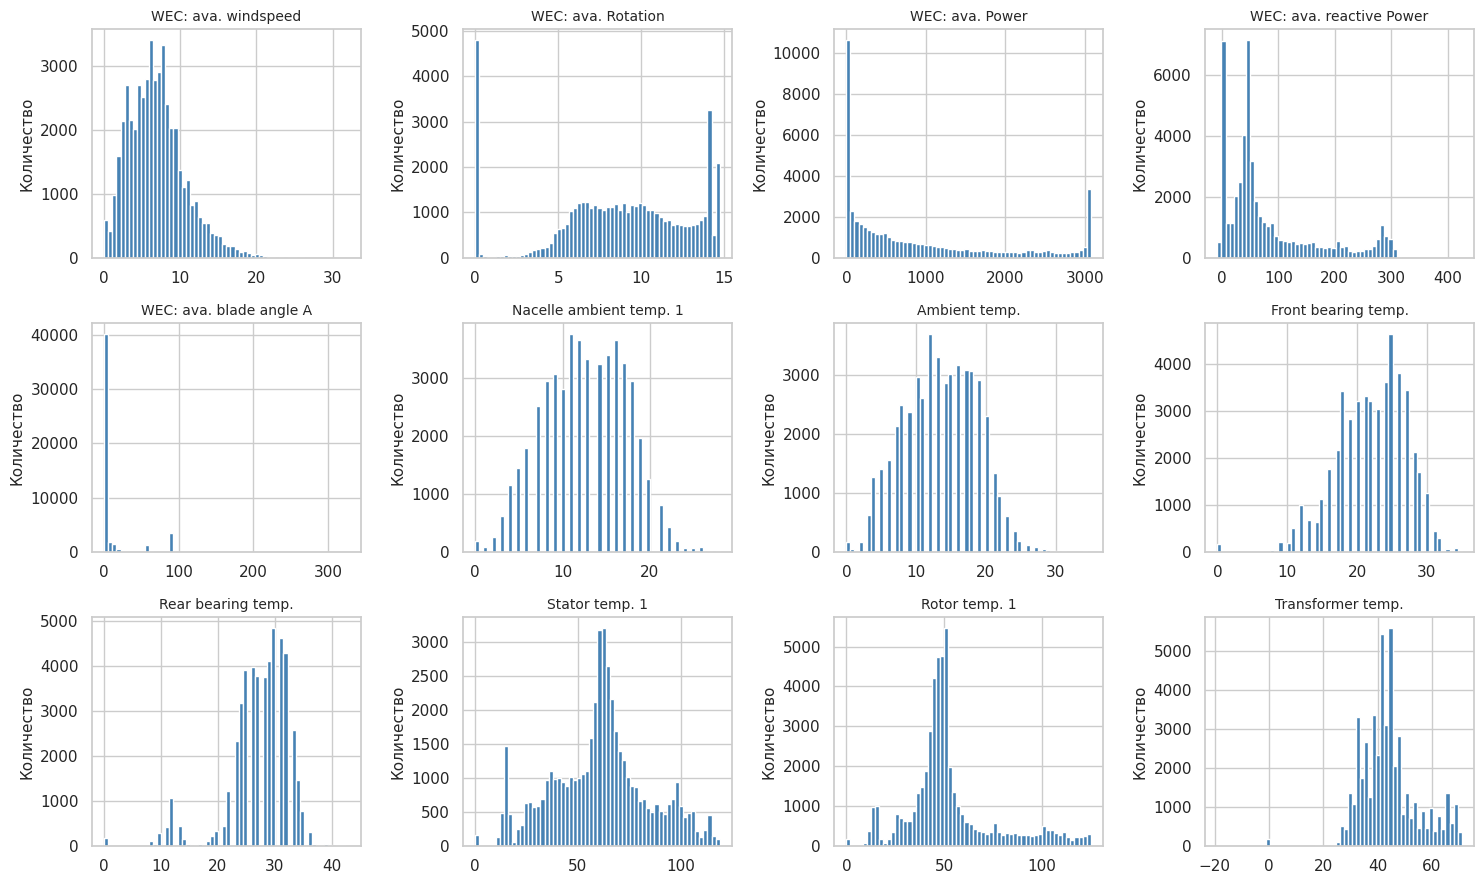

In [20]:
# Гистограммы ключевых переменных
fig, axes = plt.subplots(3, 4, figsize=(15, 9))
for ax, col in zip(axes.ravel(), key_channels):
    data = scada[col].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Количество')
plt.tight_layout()
plt.show()

**Комментарий.** Распределения скорости ветра и средней мощности типичны для ветроустановок: скорость ветра близка к распределению Вейбулла с модой около 4–6 м/с; распределение мощности — резко асимметричное с большой долей нулевых значений (турбина простаивает либо работает на малой мощности при низком ветре) и насыщением около номинальной мощности. Температурные каналы имеют унимодальные распределения, что соответствует ожиданиям для стабильно эксплуатируемой установки.

In [21]:
# Поиск выбросов по правилу межквартильного размаха (IQR)
def iqr_outliers(s: pd.Series, k: float = 3.0) -> dict:
    s = s.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - k * iqr, q3 + k * iqr
    mask = (s < low) | (s > high)
    return {'n_outliers': int(mask.sum()),
            'share_%': round(mask.mean() * 100, 3),
            'low_bound': low, 'high_bound': high}

outlier_report = pd.DataFrame(
    {col: iqr_outliers(scada[col]) for col in key_channels}
).T
outlier_report

,n_outliers,share_%,low_bound,high_bound
WEC: ava. windspeed,38.000,0.078,-9.900,23.000
WEC: ava. Rotation,0.000,0.000,-10.440,28.690
WEC: ava. Power,0.000,0.000,"-4,305.000","5,943.000"
WEC: ava. reactive Power,27.000,0.055,-205.000,341.000
WEC: ava. blade angle A,"11,969.000",24.413,0.880,1.160
Nacelle ambient temp. 1,0.000,0.000,-12.000,37.000
Ambient temp.,0.000,0.000,-15.000,41.000
Front bearing temp.,0.000,0.000,-2.000,47.000
Rear bearing temp.,165.000,0.337,7.000,49.000
Stator temp. 1,0.000,0.000,-42.000,161.000


**Комментарий.** Для строго физических величин (температура окружающей среды, скорость ветра) большое число «выбросов по IQR» обычно не означает ошибок измерения, а отражает естественную тяжесть хвостов распределения. Для дальнейшего моделирования имеет смысл различать: (а) физически невозможные значения (например, отрицательная скорость ветра, температура подшипника выше 200 °C) — это явные ошибки, и (б) редкие, но возможные значения — их следует сохранять.

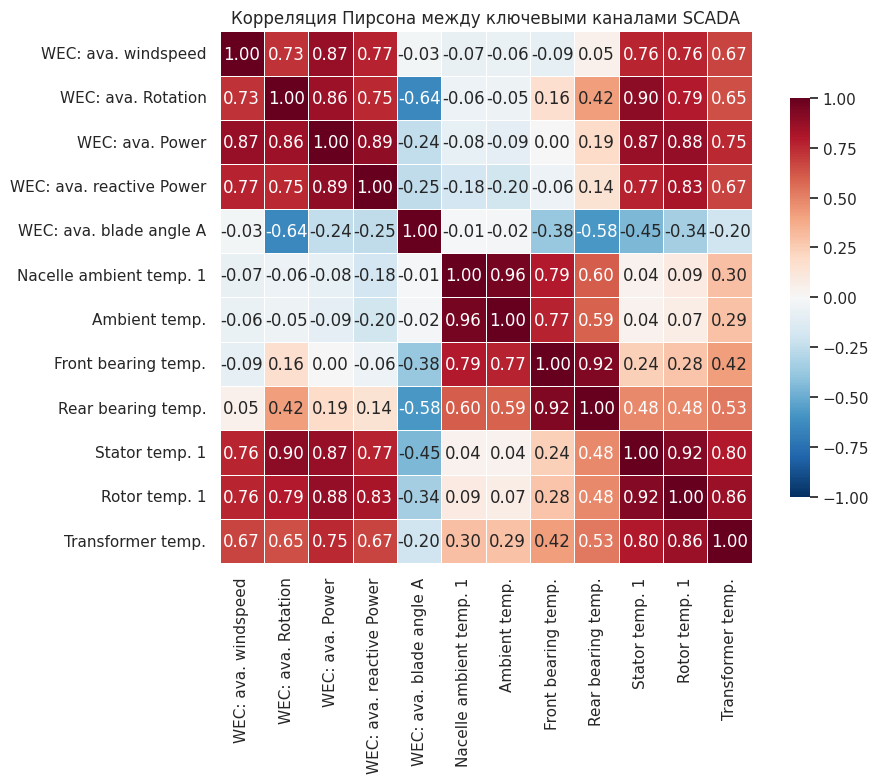

In [22]:
# Корреляционная матрица по ключевым каналам
corr = scada[key_channels].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.75})
ax.set_title('Корреляция Пирсона между ключевыми каналами SCADA')
plt.tight_layout()
plt.show()

Найдено температурных каналов: 39


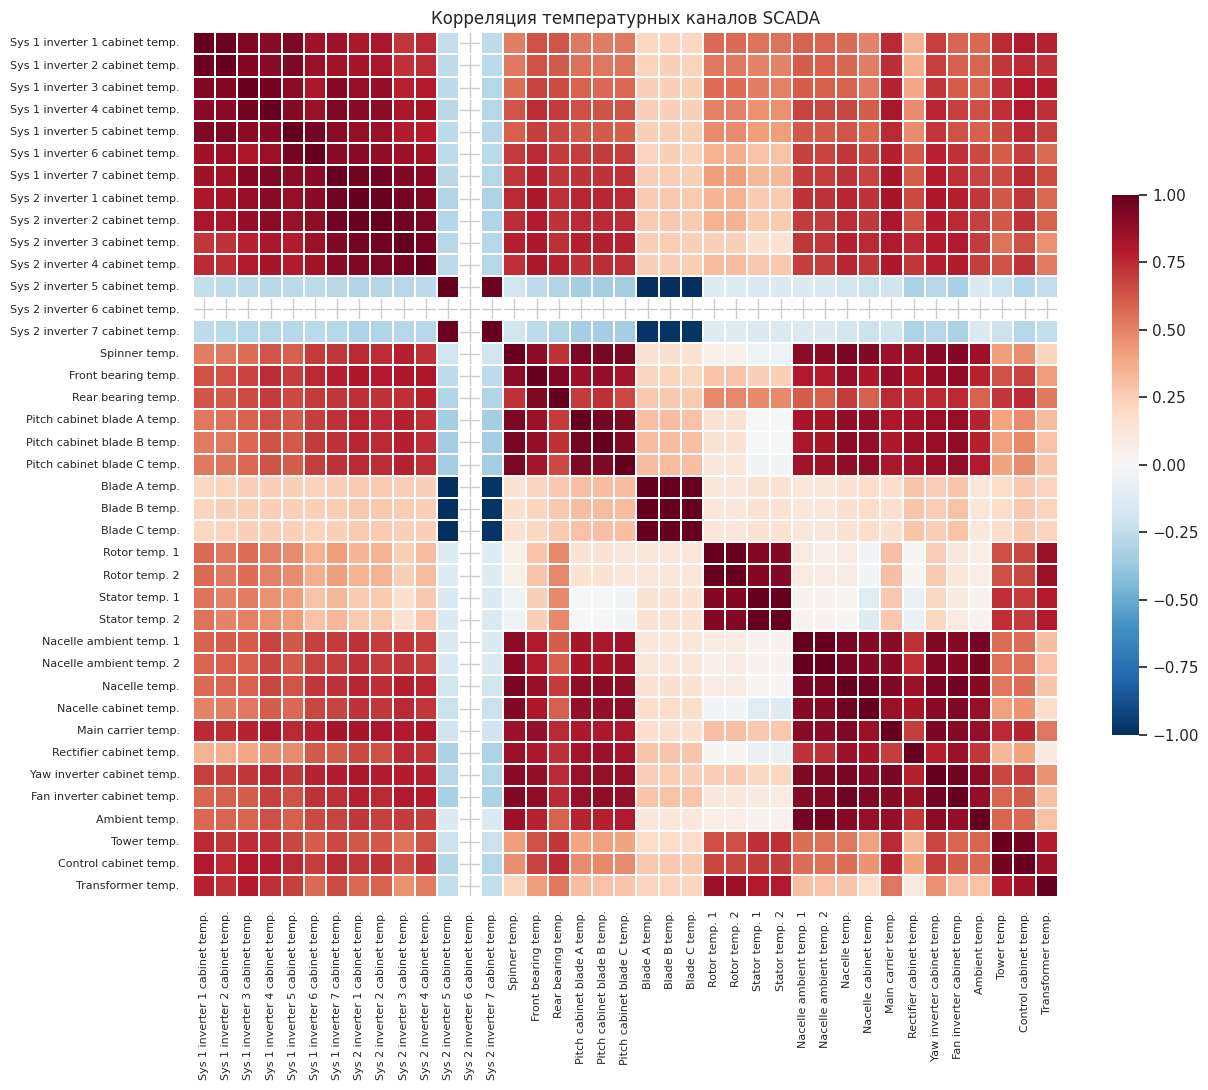

In [23]:
# Корреляционная матрица всех температурных каналов
temp_cols = [c for c in scada.columns if 'temp' in c.lower()]
print(f'Найдено температурных каналов: {len(temp_cols)}')

corr_t = scada[temp_cols].corr(method='pearson')

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(corr_t, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Корреляция температурных каналов SCADA', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

**Комментарий.** На корреляционной карте температур отчётливо проступает блочная структура: каналы одной и той же подсистемы (инверторы системы 1, инверторы системы 2, температуры лопастей, температуры подшипников) формируют плотные положительно коррелированные кластеры. Это означает значительную информационную избыточность: для дальнейшего моделирования имеет смысл либо применять методы понижения размерности (PCA по группам), либо ограничиваться представителями кластеров.

### 6.1. Сводная таблица признаков по типам отказов

Чтобы перейти от формального описания каналов к содержательной интерпретации, объединим телеметрию SCADA с метками отказов и посчитаем средние значения каналов в каждом режиме. Это позволяет ответить на вопрос: чем средний физический «портрет» установки в момент отказа того или иного типа отличается от нормального режима. Различающиеся каналы — потенциальные кандидаты в признаки для модели классификации.

In [24]:
# Подавление научной записи для удобства чтения
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Сборка объединённой таблицы: каждое окно SCADA внутри общего периода
# сопоставляется с ближайшей записью отказа (±10 минут), иначе — метка 'NF'.
scada_common_full = scada.loc[in_common].sort_values('DateTime').reset_index(drop=True)

df_combine = pd.merge_asof(
    scada_common_full,
    faults_sorted[['DateTime', 'Fault']],
    on='DateTime',
    direction='nearest',
    tolerance=pd.Timedelta(minutes=10),
)
df_combine['Fault'] = df_combine['Fault'].fillna('NF')

print(f'Размерность объединённой таблицы: {df_combine.shape}')
print('Размер выборки по режимам:')
print(df_combine['Fault'].value_counts())

Размерность объединённой таблицы: (35168, 67)
Размер выборки по режимам:
Fault
NF    34610
FF      210
EF      210
AF       79
GF       46
MF       13
Name: count, dtype: int64


In [25]:
# Группировка по типу отказа и расчёт средних значений по всем числовым каналам.
# Транспонирование делает таблицу удобной для чтения: строки — каналы, столбцы — режимы.
df_summary = df_combine.groupby('Fault').mean(numeric_only=True).T

# Упорядочиваем столбцы: NF первым, далее по убыванию частоты
col_order = [c for c in ['NF', 'FF', 'EF', 'AF', 'GF', 'MF'] if c in df_summary.columns]
df_summary = df_summary[col_order]

# Показываем последние 20 строк (как правило, наиболее интересные нижнетемпературные
# и интегральные показатели расположены в конце набора каналов).
df_summary.tail(20)

Fault,NF,FF,EF,AF,GF,MF
Blade C temp.,165.262,166.362,165.933,166.013,166.478,166.154
Rotor temp. 1,53.631,53.629,99.524,55.316,34.457,52.615
Rotor temp. 2,53.763,53.538,99.071,55.481,35.174,52.769
Stator temp. 1,62.170,59.329,100.824,68.342,43.326,66.846
Stator temp. 2,61.643,58.824,99.676,67.797,42.913,66.154
Nacelle ambient temp. 1,14.135,9.552,14.448,15.911,12.217,13.615
Nacelle ambient temp. 2,14.057,9.471,14.238,15.899,12.000,13.308
Nacelle temp.,18.000,12.543,17.281,19.633,14.174,15.769
Nacelle cabinet temp.,21.497,16.405,20.652,23.278,19.435,18.077
Main carrier temp.,18.141,14.110,19.590,20.835,13.391,16.923


In [26]:
# Оценка различимости признаков: для каждого канала считаем относительное отклонение
# среднего в режиме отказа от среднего в нормальном режиме (NF).
if 'NF' in df_summary.columns:
    nf_mean = df_summary['NF']
    rel_diff = df_summary.subtract(nf_mean, axis=0).divide(nf_mean.abs() + 1e-9, axis=0) * 100
    rel_diff = rel_diff.drop(columns='NF')
    rel_diff['max_abs_dev_%'] = rel_diff.abs().max(axis=1)
    top_features = rel_diff.sort_values('max_abs_dev_%', ascending=False).head(15)
    print('Топ-15 каналов SCADA по максимальному относительному отклонению от нормального режима:')
    print(top_features.round(2))

Топ-15 каналов SCADA по максимальному относительному отклонению от нормального режима:
Fault                                                   FF       EF        AF       GF        MF  max_abs_dev_%
WEC: ava. Nacel position including cable twisting 2562.390  120.290 -2447.540    2.980 -1377.390       2562.390
WEC: max. reactive Power                           180.220  461.380   135.180  -46.140   212.500        461.380
WEC: ava. blade angle A                            395.510  112.190   175.740  253.590    75.500        395.510
Error                                              -70.840 -100.000  -100.000  -33.440   312.180        312.180
WEC: ava. Available P force majeure reasons        103.590  216.060    22.390  -75.070    73.170        216.060
WEC: ava. Available P force external reasons       100.780  211.320    20.810  124.590    69.540        211.320
WEC: ava. available P technical reasons              7.780  211.280     3.760  129.950    73.140        211.280
WEC: ava. availab

**Комментарий.** Сводная таблица служит исходной точкой для отбора признаков. Каналы, средние значения которых заметно отличаются между классами (особенно между нормальным режимом и конкретным типом отказа), являются первыми кандидатами в обучающий набор. Полученное ранжирование по относительному отклонению удобно использовать совместно с физическим смыслом: например, ожидается, что отказ перегрева генератора (`GF`) будет лучше всего «виден» по температурам статора и ротора, а отказ воздушного охлаждения (`AF`) — по температурам узлов, находящихся в цепи охлаждения. Сопоставление статистических отклонений с такими физическими гипотезами повышает интерпретируемость дальнейшей модели.

## 7. Режимы работы по кривой мощности

Кривая мощности `мощность(скорость ветра)` — стандартный диагностический инструмент в индустрии ветроэнергетики. По её виду можно судить о корректности работы установки: точки, расположенные значительно ниже эталонной кривой, обычно соответствуют простоям, ограничениям по сети (curtailment) или дефектам.

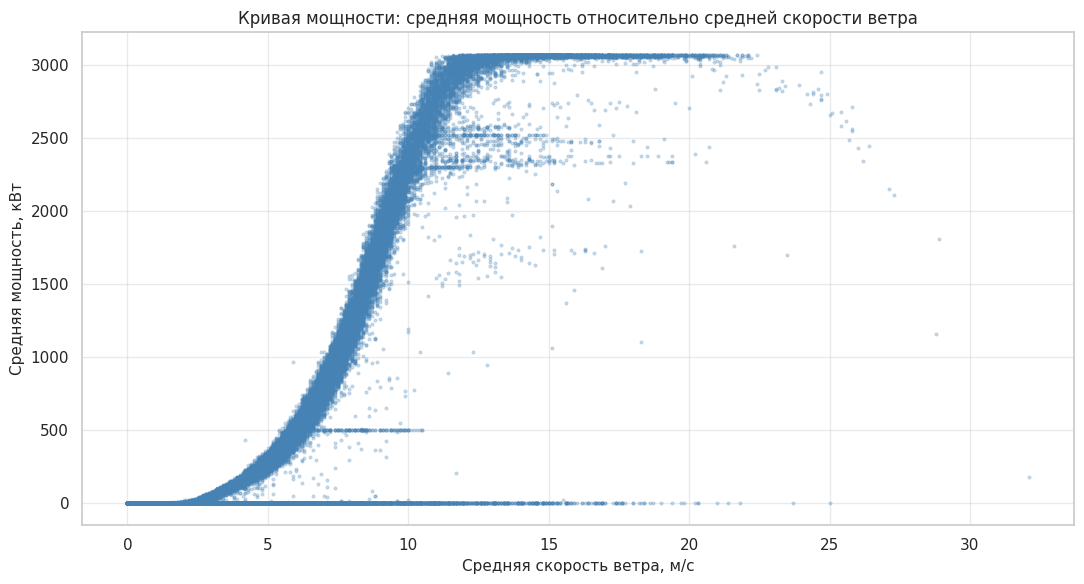

In [27]:
ws = scada['WEC: ava. windspeed']
p = scada['WEC: ava. Power']

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(ws, p, s=4, alpha=0.25, color='steelblue')
ax.set_title('Кривая мощности: средняя мощность относительно средней скорости ветра')
ax.set_xlabel('Средняя скорость ветра, м/с')
ax.set_ylabel('Средняя мощность, кВт')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

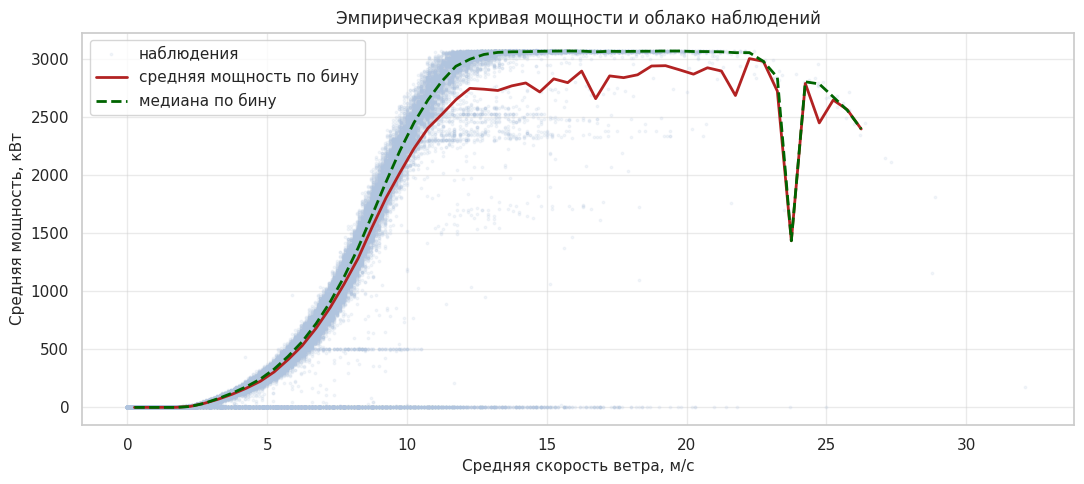

In [28]:
# Эмпирическая кривая мощности: усреднение по бинам скорости ветра
bins = np.arange(0, ws.max() + 1, 0.5)
scada['ws_bin'] = pd.cut(ws, bins)
curve = scada.groupby('ws_bin')['WEC: ava. Power'].agg(['mean', 'median', 'count'])
curve['ws_mid'] = [interval.mid for interval in curve.index]

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(ws, p, s=3, alpha=0.15, color='lightsteelblue', label='наблюдения')
ax.plot(curve['ws_mid'], curve['mean'], color='firebrick', linewidth=2, label='средняя мощность по бину')
ax.plot(curve['ws_mid'], curve['median'], color='darkgreen', linewidth=2, linestyle='--', label='медиана по бину')
ax.set_xlabel('Средняя скорость ветра, м/с')
ax.set_ylabel('Средняя мощность, кВт')
ax.set_title('Эмпирическая кривая мощности и облако наблюдений')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

**Комментарий.** На графике видны три области: (1) при скоростях ветра ниже стартовой (примерно 3 м/с) мощность близка к нулю — установка не работает; (2) в рабочем диапазоне (3–12 м/с) наблюдается характерный кубический рост; (3) при высоких скоростях ветра кривая выходит на насыщение, что соответствует работе на номинальной мощности с активным регулированием угла лопастей.

Существенным наблюдением является наличие точек *ниже* эталонной кривой при высоких скоростях ветра: при скорости 10–15 м/с турбина в части записей выдаёт нулевую или сильно сниженную мощность. Эти точки являются кандидатами на разметку как «аномальные эпизоды» — они с высокой вероятностью соответствуют простоям, сервисным окнам или ограничениям подачи.

In [29]:
# Оценка коэффициента использования установленной мощности (capacity factor)
rated_power = p.quantile(0.99)  # робастная оценка номинальной мощности
capacity_factor = p.mean() / rated_power * 100
downtime_share = (p <= 0).mean() * 100

print(f'Робастная оценка номинальной мощности (99-й перцентиль): {rated_power:,.0f} кВт')
print(f'Коэффициент использования установленной мощности (CF):   {capacity_factor:.1f} %')
print(f'Доля записей с нулевой мощностью:                        {downtime_share:.1f} %')

Робастная оценка номинальной мощности (99-й перцентиль): 3,069 кВт
Коэффициент использования установленной мощности (CF):   30.7 %
Доля записей с нулевой мощностью:                        13.3 %


**Комментарий.** Полученный коэффициент использования установленной мощности находится в диапазоне типовых отраслевых значений (обычно 25–45 % для береговых ветроустановок). Доля периодов простоя (нулевая мощность) представляет собой важную метрику для последующего моделирования доступности оборудования.

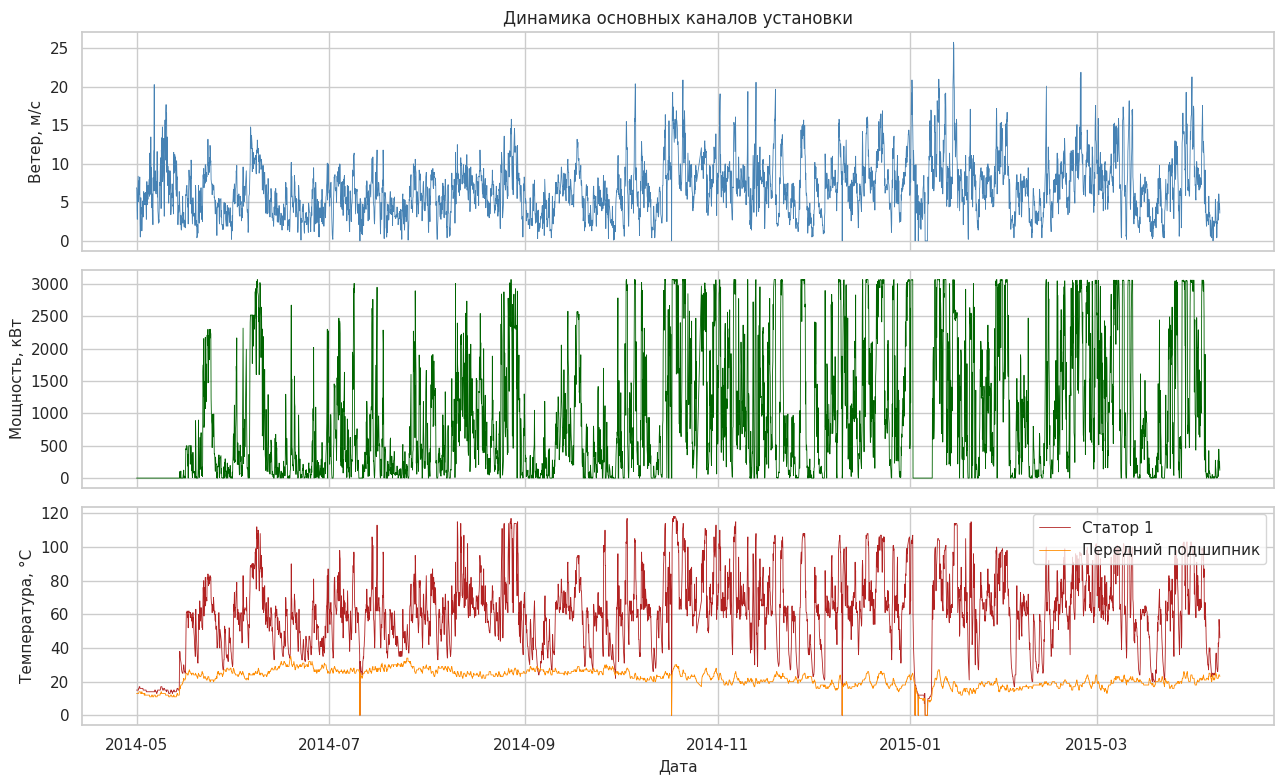

In [30]:
# Совместная динамика ключевых каналов во времени (с прореживанием для наглядности)
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

step = max(1, len(scada) // 4000)  # прореживаем, чтобы график оставался читаемым
scada_plot = scada.iloc[::step]

axes[0].plot(scada_plot['DateTime'], scada_plot['WEC: ava. windspeed'],
             linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Ветер, м/с')
axes[0].set_title('Динамика основных каналов установки')

axes[1].plot(scada_plot['DateTime'], scada_plot['WEC: ava. Power'],
             linewidth=0.6, color='darkgreen')
axes[1].set_ylabel('Мощность, кВт')

axes[2].plot(scada_plot['DateTime'], scada_plot['Stator temp. 1'],
             linewidth=0.6, color='firebrick', label='Статор 1')
axes[2].plot(scada_plot['DateTime'], scada_plot['Front bearing temp.'],
             linewidth=0.6, color='darkorange', label='Передний подшипник')
axes[2].set_ylabel('Температура, °C')
axes[2].set_xlabel('Дата')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 8. Сводные выводы

**Качество данных.**

1. Все три источника содержат согласованные временные диапазоны и пригодны для совместного анализа. Шаг дискретизации SCADA близок к 10 минутам и в целом стабилен, хотя присутствуют редкие более длинные разрывы.
2. Журналы статусов и отказов имеют событийный характер: их следует привязывать к окнам SCADA, а не наоборот.
3. Логические поля журнала статусов (`Service`, `FaultMsg`) изначально прочитаны как строки и требуют принудительного приведения.

**Структура отказов.**

1. Доминируют отказы класса `FF` (Feeding Fault) и `EF` (Excitation Fault) — около трёх четвертей всех событий. Это указывает на приоритетную зону внимания при разработке системы предиктивного обслуживания: электрические подсистемы — преобразование энергии и возбуждение генератора.
2. Отказы перегрева генератора (`GF`) и системы воздушного охлаждения (`AF`) составляют меньшую долю, но потенциально допускают раннее обнаружение по температурным каналам SCADA, что делает их особенно интересными для построения моделей предиктивного мониторинга. Отказы электросети (`MF`) — внешний фактор и при моделировании надёжности самой установки могут рассматриваться отдельно.

**Структура телеметрии.**

1. Среди 65 каналов SCADA значительную долю составляют температуры; они образуют плотно скоррелированные кластеры по подсистемам. При построении моделей это требует либо снижения размерности, либо отбора по физическому смыслу.
2. Распределения ключевых физических величин соответствуют отраслевым ожиданиям: ветер близок к Вейбуллу, мощность — резко асимметрична с насыщением.

**Эксплуатационные характеристики.**

1. Кривая мощности имеет ожидаемый вид с тремя характерными участками. Однако присутствуют наблюдения, существенно отклоняющиеся вниз от ожидаемой кривой при достаточном ветре, — это естественные кандидаты на разметку как аномальные.
2. Доля интервалов с нулевой мощностью представляет собой важный показатель доступности, который следует использовать при бизнес-оценке моделей.

**Рекомендации к следующим шагам.**

1. Сформировать единую таблицу: каждое 10-минутное окно SCADA размечается ближайшим статусом и флагом отказа в окрестности (например, в окне ±60 минут). Это база для задачи классификации «предотказное состояние / нормальная работа».
2. Произвести фильтрацию физически невозможных значений (например, температуры за пределами рабочего диапазона датчиков) — отдельно от естественных хвостов распределений.
3. Для температурных каналов рассмотреть переход к признакам на уровне подсистем: средние и стандартные отклонения по кластеру вместо отдельных датчиков.
4. Построить отдельные модели по типам отказов, поскольку малые классы (`MF`, `GF`, `AF`) требуют либо собственного подхода (one-class, novelty detection), либо балансировки выборки.
5. На этапе валидации использовать сценарий с разделением по времени (а не случайным образом), чтобы корректно оценить обобщающую способность модели на будущих данных.